In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns


# KGE boxplot:

In [79]:

df = pd.read_csv(r'C:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\Simulation_results\streamflow_performance_metrics.csv')
# 

df = df.set_index('gauge_id')
df.describe()

,KGE,NSE
count,2525.000000,2525.000000
mean,-3.554628,-74.463536
std,13.843424,838.598076
min,-244.852837,-20740.953861
25%,-2.050408,-8.513121
50%,-0.494394,-2.758053
75%,0.077663,-0.404958
max,0.885714,0.833619


In [85]:
final_calibrated_params = pd.read_csv(r'C:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\SCE_cal_params\final_calibrated_params.csv')

<AxesSubplot:>

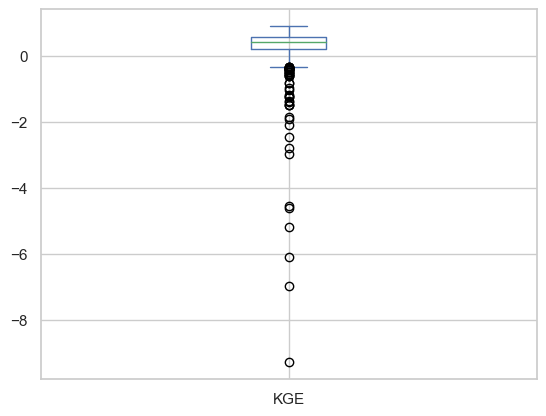

In [ ]:
final_calibrated_params['KGE'].plot(kind='box', showfliers+)

return interval


ValueError: Could not interpret value `scenario` for `x`. An entry with this name does not appear in `data`.

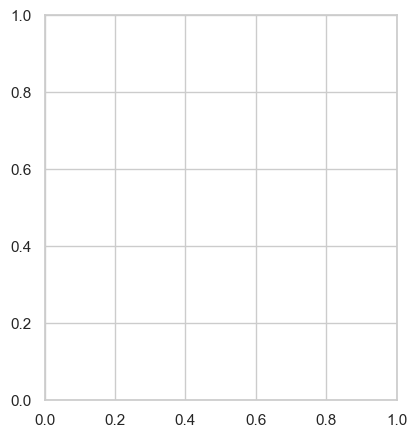

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame
plt.figure(figsize=(10, 5))

# Boxplot for KGE
plt.subplot(1, 2, 1)
sns.boxplot(x='scenario', y='KGE', data=df, palette='Set2', showfliers=False)
plt.title('KGE by Scenario')
plt.xlabel('Scenario')
plt.ylabel('KGE')

# Boxplot for NSE
plt.subplot(1, 2, 2)
sns.boxplot(x='scenario', y='NSE', data=df, palette='Set2', showfliers=False)
plt.title('NSE by Scenario')
plt.xlabel('Scenario')
plt.ylabel('NSE')

plt.tight_layout()
plt.show()


In [29]:
df = pd.read_csv(r'C:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\Bayesian_DA_Budyko_modeling\Simulation_results\results_streamflow_01013500.csv')
df.columns

Index(['Q_obs', 'Q_ke', 'Q_ke_NLDA', 'Q_b', 'Q_b_DA', 'Q_b_ETNL_DA'], dtype='object')

In [61]:

df = pd.read_csv(r'C:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\Bayesian_DA_Budyko_modeling\Simulation_results\results_streamflow_01013500.csv')
# df.set_index('gauge_id', inplace=True)

kge_cols = ['Q_Base_Q_KGE', 'Q_B_Q_KGE', 'Q_ET_DA_Q_KGE']
labels = ['Q (Base Model, without DA)', 
          'Q (Budyko informed, without DA)', 
          'Q (Budyko informed, with DA)']

# Replace inf values and keep only positive values
df_clean = df[kge_cols].replace([np.inf, -np.inf], np.nan).dropna()
df_positive = df_clean[df_clean > 0]

# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
sns.boxplot(data=df_positive, palette="Set2", showfliers=False)

# Correctly set x-axis labels
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=0, fontsize=14)
plt.ylabel("KGE", fontsize=12)
plt.title("Comparison of KGE Metrics Across Three Scenarios", fontsize=16, fontweight='bold')
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\hdagne1\\Box\\Dr.Mesfin Research\\Codes\\DA\\DA_Github_repo\\Bayesian_DA_Budyko_modeling\\Bayesian_DA_Budyko_modeling\\Simulation_results\\results_streamflow_01013500.csv'

# CDF KGE:

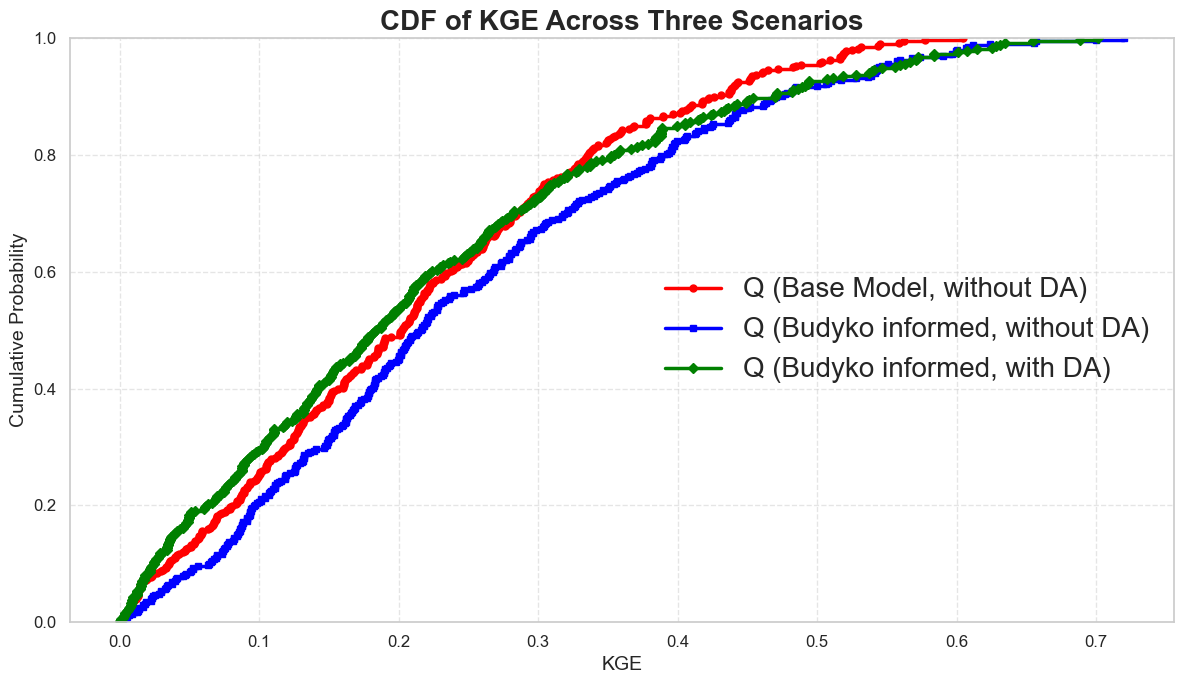

In [60]:
df_positive = df_clean[df_clean > 0]
# Custom styling for lines
# line_styles = ['-', '--', ':']
markers = ['o', 's', 'D']
colors = ['red', 'blue', 'green']
labels = ['Q (Base Model, without DA)', 'Q (Budyko informed, without DA)', 'Q (Budyko informed, with DA)']
# Plot CDF
sns.set(style="whitegrid")
plt.figure(figsize=(12,7))

for i, col in enumerate(df_positive.columns):
    sns.ecdfplot(
        df_positive[col],
        label=col,
        linewidth=2.5,
        # linestyle=line_styles[i],
        color=colors[i],
        marker=markers[i],
        markersize=5
    )

plt.title("CDF of KGE Across Three Scenarios", fontsize=20, fontweight='bold')
plt.xlabel("KGE", fontsize=14)
plt.ylabel("Cumulative Probability", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=20,loc='center right', labels=labels, frameon=False)
plt.tight_layout()
plt.show()


In [77]:
Result_DIR = r"C:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\Simulation_results"
df = pd.read_feather(os.path.join(Result_DIR, "results_streamflow_01013500.feather"))
df = df.set_index('time')
df

,Q_obs,Q_nldas,Q_ke,Q_ke_NLDA,Q_b,Q_b_DA,Q_b_ETNL_DA
time,,,,,,,
2000-01-01,24.560242,12.874130,787.451898,787.362543,787.451607,577.300434,9.165225
2000-02-01,14.980075,7.697712,246.131962,245.937342,246.131446,12.282951,12.467023
2000-03-01,29.484455,54.252233,94.764525,94.531242,94.763790,18.499730,19.195066
2000-04-01,212.868468,51.150878,102.477177,102.242402,102.474864,66.078262,69.165192
2000-05-01,166.602158,97.944400,106.276549,106.056661,106.271624,65.412577,65.414269
...,...,...,...,...,...,...,...
2014-08-01,17.535583,54.751890,77.318856,77.116154,77.314633,32.295781,32.187206
2014-09-01,9.023016,32.583507,71.344296,71.134648,71.341061,43.869049,44.033092
2014-10-01,9.323784,46.073770,105.235903,105.013605,105.232902,75.089939,75.090713


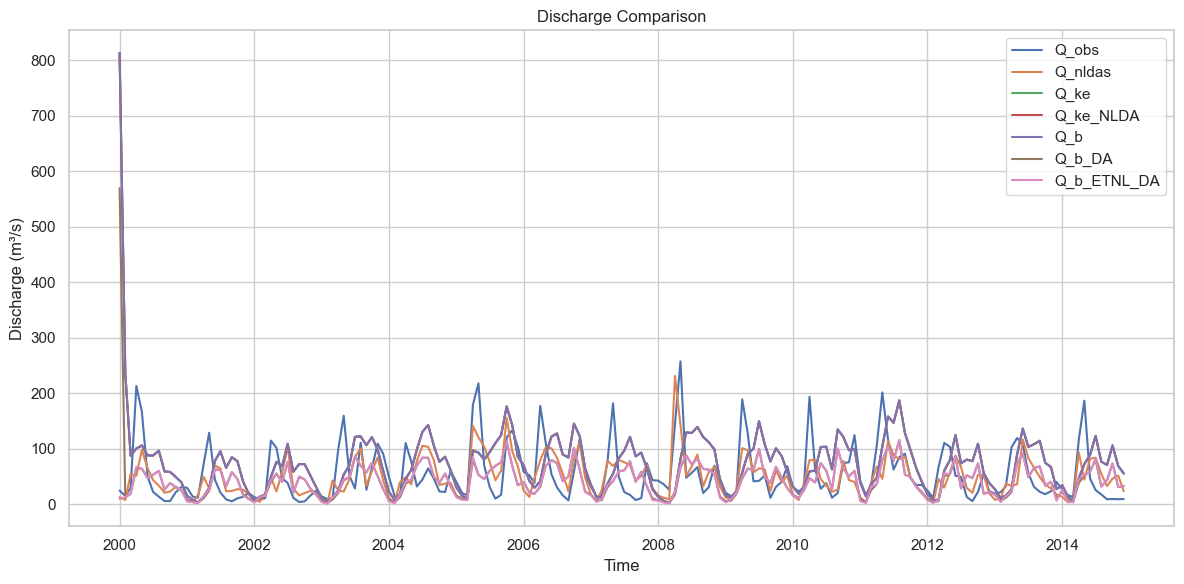

In [59]:
import matplotlib.pyplot as plt

# Assuming df is your DataFrame
plt.figure(figsize=(12, 6))

for col in df.columns:
    plt.plot(df.index, df[col], label=col)

plt.xlabel('Time')
plt.ylabel('Discharge (m³/s)')
plt.title('Discharge Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


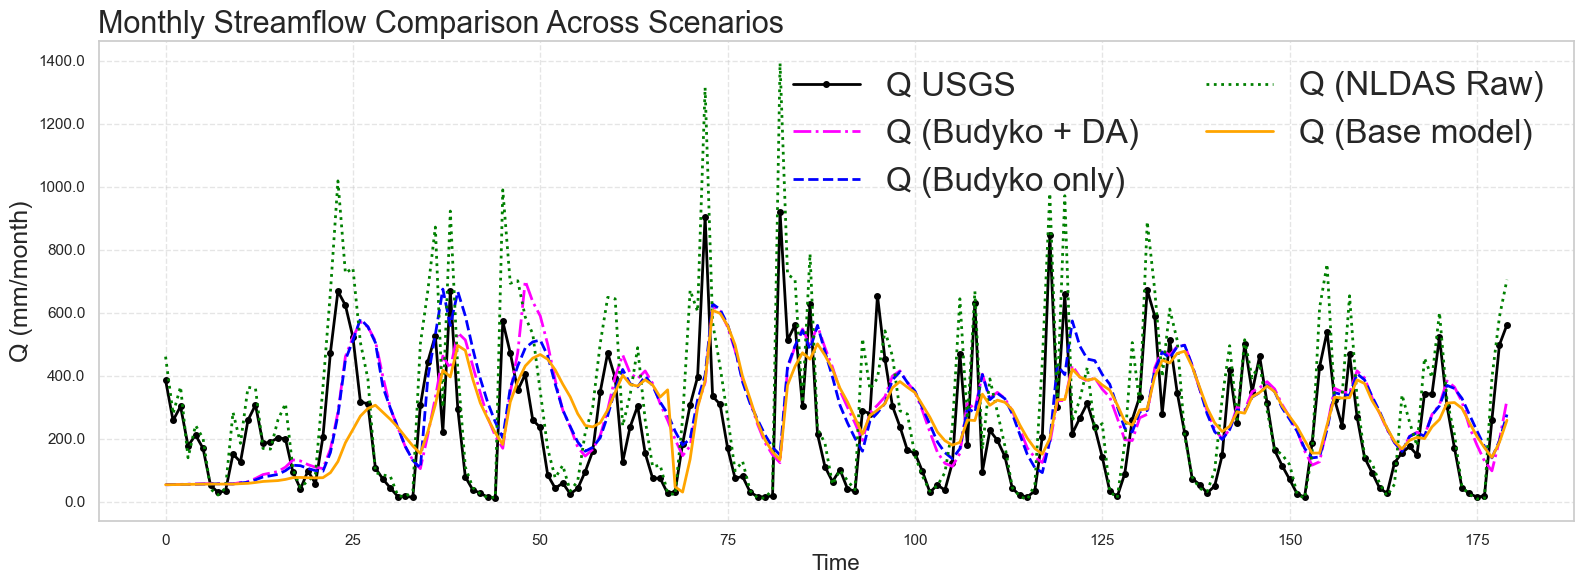

In [25]:
import matplotlib.ticker as mtick
Result_DIR = r"C:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\Simulation_results\enkf_timeseries"
df = pd.read_feather(os.path.join(Result_DIR, "12043000_enkf_timeseries.feather"))

# df.set_index('Date', inplace=True)
# df = df.loc['2000-10-01':'2014-12-01']

plt.figure(figsize=(16, 6))#, dpi=200)

# Plot each scenario with improved aesthetics
df['Q_USGS_obs'].plot(label='Q USGS', color='black', lw=2, linestyle='-', marker='o', markersize=4)
df['Q_ET_DA_Q_sim'].plot(label='Q (Budyko + DA)', color='magenta', linestyle='-.', lw=2)
df['Q_B_Q_sim'].plot(label='Q (Budyko only)', color='blue', linestyle='--', lw=2)
df['Q_NLDAS_input'].plot(label='Q (NLDAS Raw)', color='green', linestyle=':', lw=2)
df['Q_Base_Q_sim'].plot(label='Q (Base model)', color='orange', linestyle='-', lw=2)

# Labels, title, and legend
plt.xlabel('Time', fontsize=16)
plt.ylabel('Q (mm/month)', fontsize=18)
plt.title('Monthly Streamflow Comparison Across Scenarios', fontsize=22, loc='left')

# Scientific formatting of y-axis
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))

# Grid, minor ticks, and legend styling
plt.grid(True, which='major', linestyle='--', alpha=0.5)
plt.minorticks_on()
plt.legend(fontsize=24, frameon=0, loc='upper right', ncol=2)

plt.tight_layout()
plt.show()


In [26]:
df

,Date,P_input,PET_input,Q_USGS_obs,Q_NLDAS_input,ET_NLDAS_obs,ET_Budyko,Q_Base_Q_sim,Q_Base_ET_sim,Q_Base_S_sim,Q_Base_G_sim,Q_B_Q_sim,Q_B_ET_sim,Q_B_S_sim,Q_B_G_sim,Q_ET_DA_Q_sim,Q_ET_DA_ET_sim,Q_ET_DA_S_sim,Q_ET_DA_G_sim
0,2000-01-01,373.789886,0.030138,386.043623,460.484670,15.552537,0.030136,53.931977,0.017714,20.000000,519.457300,53.926423,0.023394,20.000000,519.843316,53.925308,0.018267,20.000000,519.512023
1,2000-02-01,233.045410,0.051620,258.044458,279.220412,19.106337,0.051609,54.360269,0.029157,19.999999,519.620124,54.394590,0.039473,20.000000,520.386841,54.466142,0.033961,19.999998,519.882683
2,2000-03-01,231.114868,0.113771,302.827115,364.855286,40.101387,0.113715,54.636527,0.069102,20.000000,519.955236,54.748018,0.079798,19.999999,521.391343,54.867138,0.078640,19.999999,520.524146
3,2000-04-01,166.852173,0.178278,177.135287,139.510003,44.716206,0.178088,55.159963,0.106432,19.999999,520.051646,55.375306,0.115109,19.999997,521.758765,55.610811,0.136496,19.999999,520.735142
4,2000-05-01,231.482178,0.201190,211.817902,242.619434,62.606709,0.201015,55.338263,0.124161,19.999998,520.336203,55.602080,0.124937,19.999996,522.885899,55.881514,0.186322,19.999996,521.391686
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2014-08-01,18.176933,0.207488,14.431741,8.929079,36.997871,0.205146,207.415455,0.000000,19.999978,0.240039,224.838447,0.416851,19.999842,0.240058,179.900722,41.886087,19.999912,0.240036
176,2014-09-01,105.096397,0.168177,18.487720,10.373540,37.349785,0.167908,171.940486,0.000000,19.999958,0.240063,175.855956,0.083954,19.999827,0.240072,129.234004,36.615190,19.999929,0.240038
177,2014-10-01,469.899017,0.081435,260.997560,393.539408,31.329666,0.081421,140.769101,0.000000,20.000000,0.240000,139.248029,0.040710,19.999780,0.240059,97.987573,17.878079,19.999972,0.240064
178,2014-11-01,383.692596,0.053679,498.174403,587.098147,17.213943,0.053672,188.821492,0.000000,19.999998,0.240001,193.660167,0.695964,19.999735,0.240000,195.882629,13.208773,20.000000,0.240183


# NWM data: